In [1]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.preprocessing import StandardScaler

# Load the data. 
Load the data from the file and group it by peptide and time and concentration. 

In [2]:
data = pd.read_hdf("../../TC_Antigen_encoding-main/initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
MARKERS = data.columns
ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']

In [3]:
df = data.loc[(data.index.get_level_values('CellType') == 'OT-1') & 
                       (data.index.get_level_values('Concentration') == '1uM') & 
                       (data.index.get_level_values('Replicate') == '1') &
                       (data.index.get_level_values('Time') >= 0.0) & # [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
                       (data.index.get_level_values('Peptide').isin(ANTIGENS))
                    ]

In [4]:
# Normalize the data. 
normal_df = pd.DataFrame(StandardScaler().fit_transform(df), columns=df.columns, index=df.index)

In [5]:
# A function to get a dataframe having only specific peptides and times. 
def get_population(peptide, time):
    res = df.loc[
        (df.index.get_level_values('Peptide') == peptide) & 
        (df.index.get_level_values('Time') == time)
    ]

    return res.reset_index()[MARKERS]

In [6]:
get_population('N4', 4.0)

Marker,FSC-A,SSC-A,CD25,CD38,Granzyme B,CD2,CD27,CD45RA,CD4,CD86,...,CD126,Proliferation,ICOS,IRF8,CD19,MHC-II,CD45,CD44,CX3CR1,CD8a
0,284,132,717,747,419,0,444,0,170,568,...,737,904,0,1023,648,595,0,574,513,0
1,335,249,251,269,250,429,369,292,249,303,...,305,862,214,271,281,318,589,473,528,283
2,477,270,276,285,289,117,287,298,254,309,...,294,894,306,283,250,233,511,603,447,207
3,585,203,281,268,311,131,274,314,251,297,...,286,873,291,271,252,245,485,599,517,251
4,263,117,294,257,268,223,285,313,282,300,...,271,838,251,436,265,299,430,287,423,290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3608,394,86,246,286,298,311,280,312,285,284,...,294,889,227,340,266,275,519,294,567,275
3609,333,56,295,253,293,233,273,272,273,296,...,288,794,173,299,257,350,534,374,521,274
3610,404,123,283,277,279,301,283,301,267,295,...,262,838,362,283,254,185,598,257,432,297
3611,476,216,290,253,304,104,279,313,263,285,...,282,892,387,263,248,153,376,638,517,235


# Population Summary
Now we can summarize the data at different time points and with different peptides. 

In [7]:
def plot_hists(df, title=None): 
    fig, axes = plt.subplots(nrows=5, ncols=6, figsize=(20,10))
    axes = axes.flatten()

    for i, column in enumerate(df.columns):
        axes[i].hist(df[column], bins=20)
        axes[i].set_title(column)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')

    if not (title == None):
        fig.suptitle(title)

    plt.tight_layout()

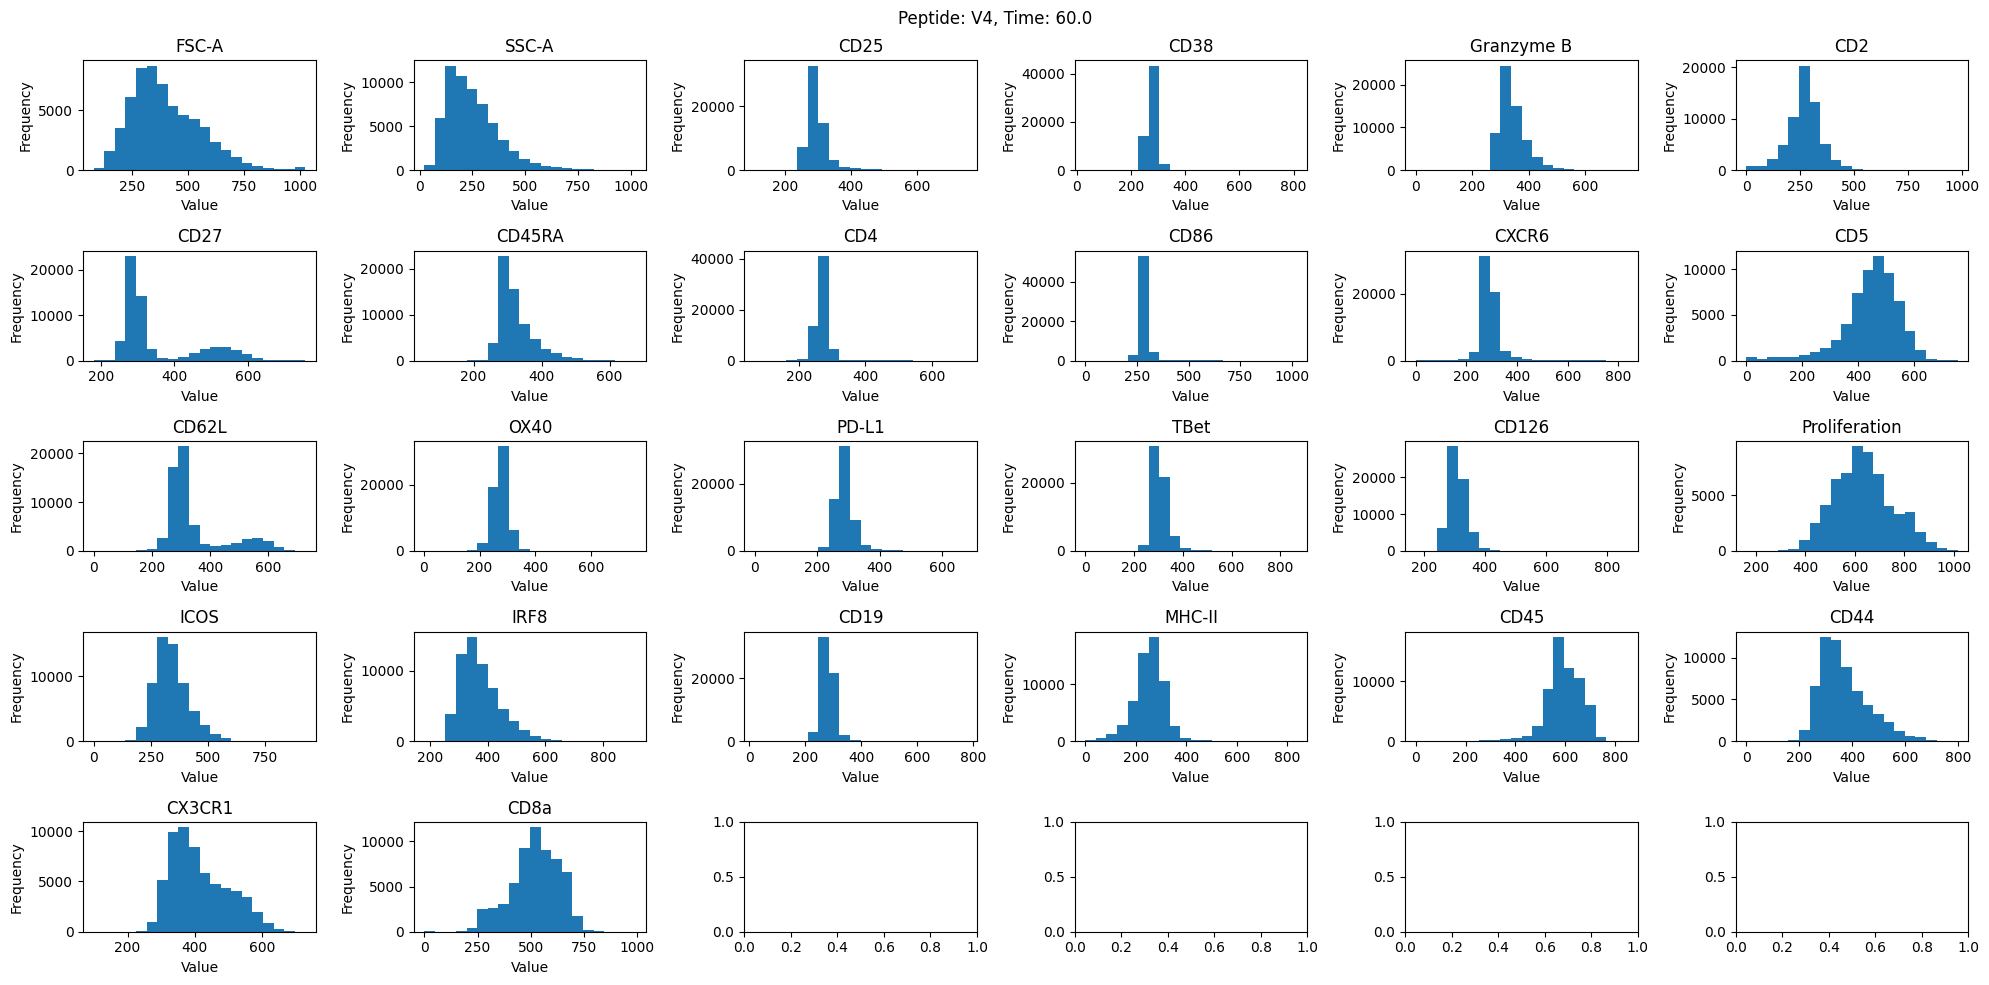

In [8]:
plot_hists(get_population('V4', 60.0), title=f"Peptide: V4, Time: 60.0")

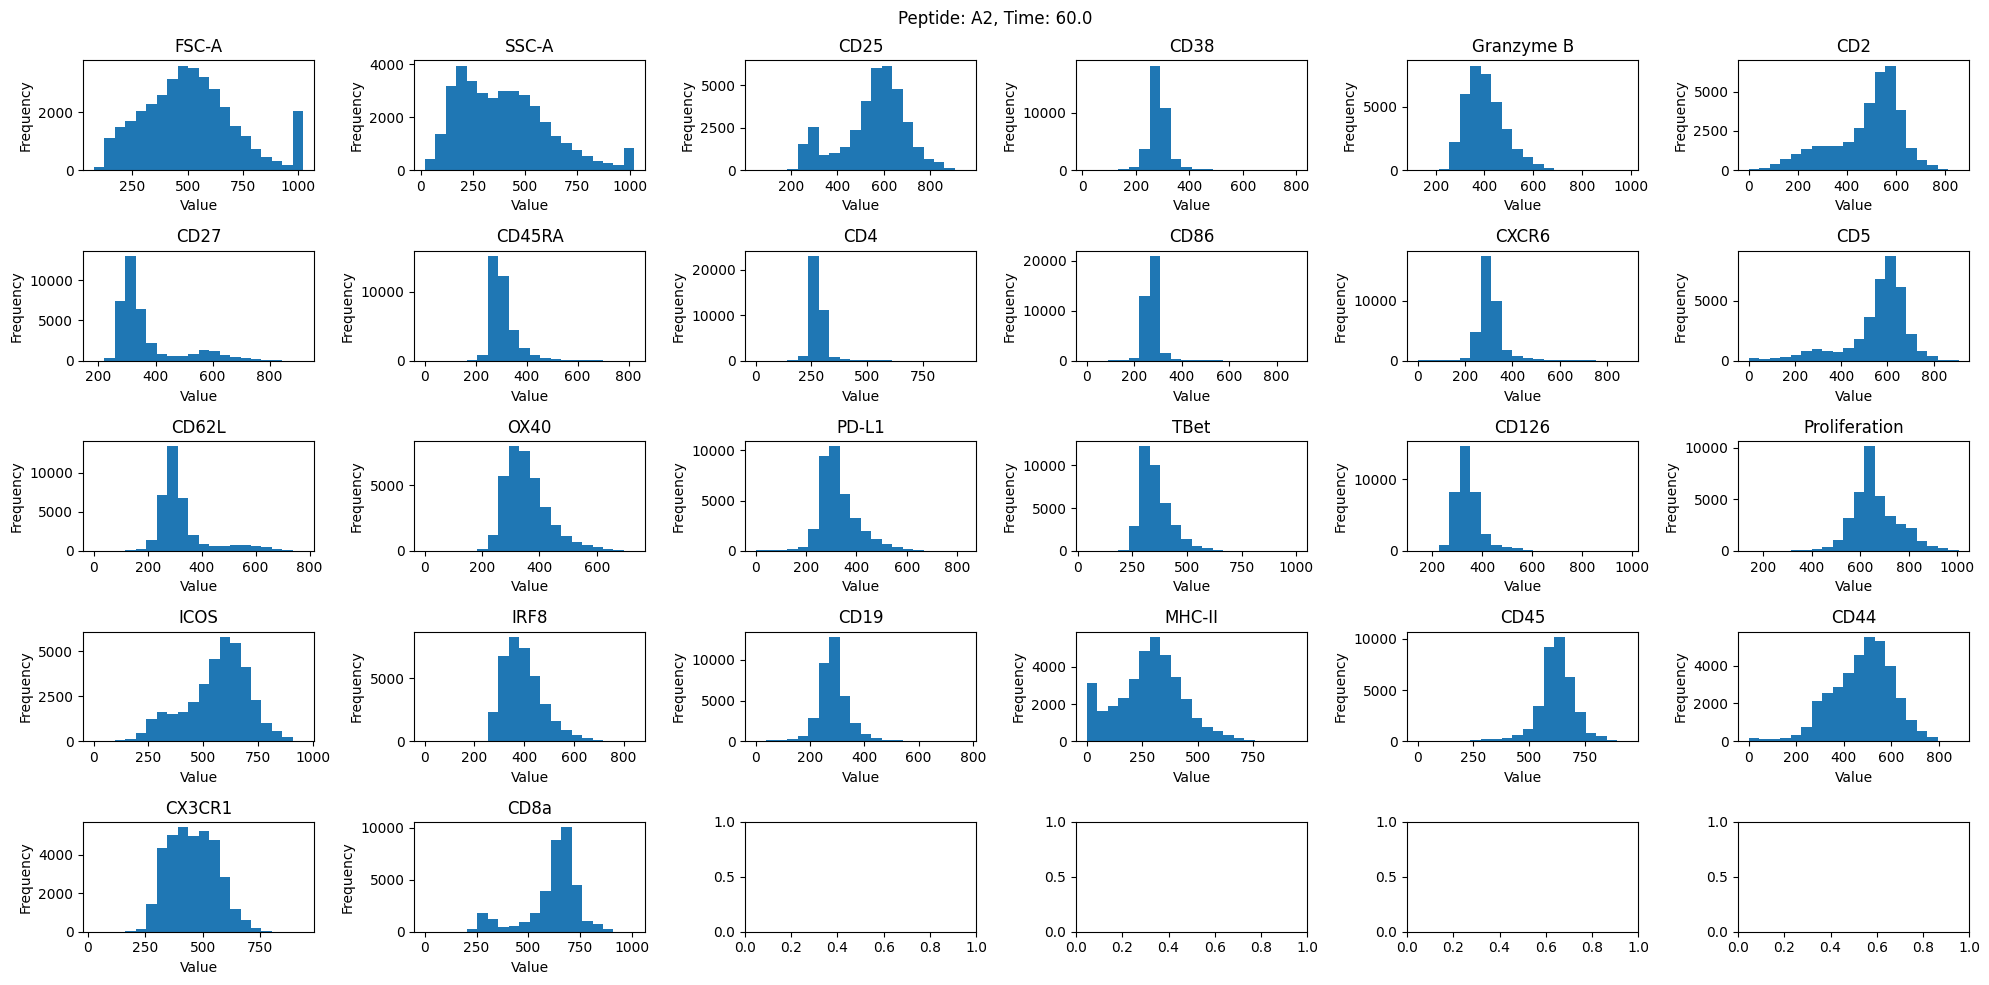

In [9]:
plot_hists(get_population('A2', 60.0), title=f"Peptide: A2, Time: 60.0")